In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df_touchpoints = pd.read_csv("../data/touchpoints_clean.csv")

# Étape 1 : Exploration des parcours (Léopold)

In [ ]:
# Aperçu des données
df_touchpoints.head()

In [ ]:
# Répartition des conversions
value_counts = df_touchpoints['is_last_before_conversion'].value_counts()
print("Répartition is_last_before_conversion :")
print(value_counts)

In [ ]:
# Nombre moyen de touchpoints par client
touchpoints_per_client = df_touchpoints.groupby('customer_id').size()
average_touchpoints = touchpoints_per_client.mean()
print(f"Nombre moyen de touchpoints par client : {average_touchpoints:.2f}")

# Boxplot de la répartition
plt.figure(figsize=(10, 4))
plt.boxplot(touchpoints_per_client, vert=False)
plt.title('Répartition du nombre de touchpoints par client')
plt.xlabel('Nombre de touchpoints')
plt.show()

In [ ]:
# Durée moyenne d'un parcours
df_touchpoints['timestamp'] = pd.to_datetime(df_touchpoints['timestamp'])

first = df_touchpoints.groupby('customer_id')['timestamp'].min()
last = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1].groupby('customer_id')['timestamp'].max()

average_duration = ((last - first).dropna().dt.total_seconds() / 3600).mean()
print(f"Durée moyenne d'un parcours : {average_duration:.2f} heures")

In [ ]:
# Canaux les plus présents en première et dernière position
first_touch_exp = df_touchpoints.groupby('customer_id').first()
channel_premiere_position = first_touch_exp['channel'].value_counts()

last_touch_exp = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1].groupby('customer_id').last()
channel_derniere_position = last_touch_exp['channel'].value_counts()

print("Canaux en première position :")
print(channel_premiere_position)
print("\nCanaux en dernière position avant conversion :")
print(channel_derniere_position)

In [ ]:
# Analyse des séquences - Top 5 trigrammes
sequences = df_touchpoints.sort_values('timestamp').groupby('customer_id')['channel'].apply(list)
trigrams = Counter(gram for s in sequences for gram in zip(s, s[1:], s[2:]))

print("Top 5 trigrammes :")
for seq, n in trigrams.most_common(5):
    print(f"  {' → '.join(seq)} : {n}")

# Comparaison touchpoints convertis vs non convertis
lengths = df_touchpoints.groupby('customer_id')['channel'].count()
converted_exp = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1]['customer_id'].unique()

print(f"\nConvertis     : {lengths[lengths.index.isin(converted_exp)].mean():.1f} touchpoints en moyenne")
print(f"Non convertis : {lengths[~lengths.index.isin(converted_exp)].mean():.1f} touchpoints en moyenne")

In [ ]:
# Matrice de transition (exploration)
df_sorted = df_touchpoints.sort_values(['customer_id', 'timestamp'])
transitions = []

for cid, group in df_sorted.groupby('customer_id'):
    channels_exp = group['channel'].tolist()
    end = 'Conversion' if group['is_last_before_conversion'].max() == 1 else 'Null'
    for a, b in zip(['Start'] + channels_exp, channels_exp + [end]):
        transitions.append((a, b))

trans_df = pd.DataFrame(transitions, columns=['from', 'to'])
matrix_exploration = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index').round(3)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matrix_exploration, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title("Matrice de transition (Exploration)")
plt.tight_layout()
plt.show()

# Étape 2 : Modèles d'Attribution Heuristiques (Younes)

In [13]:
# FIRST TOUCH

converted_ids = df_touchpoints[df_touchpoints['converted'] == 1]['customer_id'].unique()
df_converted = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]

first_touch_attribution = (
    df_converted[df_converted['position'] == 1]
    .groupby('channel')
    .size()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
first_touch_attribution['%'] = (
    first_touch_attribution['conversions'] / first_touch_attribution['conversions'].sum() * 100
).round(1)

first_touch_attribution

,channel,conversions,%
1,display,44804,30.0
4,social,44672,30.0
0,affiliate,44487,29.8
2,email,7612,5.1
3,retargeting,7575,5.1


In [14]:
# répartition budget first touch
first_channel = (
    df_converted[df_converted['position'] == 1][['customer_id', 'channel']]
    .rename(columns={'channel': 'first_channel'})
)

cost_per_customer = df_converted.groupby('customer_id')['cost'].sum().reset_index()

df_budget = cost_per_customer.merge(first_channel, on='customer_id')

budget_first_touch = (
    df_budget.groupby('first_channel')['cost']
    .sum()
    .reset_index()
    .rename(columns={'first_channel': 'channel', 'cost': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_first_touch['budget'] = budget_first_touch['budget'].round(2)
budget_first_touch['%'] = (
    budget_first_touch['budget'] / budget_first_touch['budget'].sum() * 100
).round(1)

budget_first_touch

,channel,budget,%
0,display,2944164.83,32.3
1,affiliate,2935242.72,32.2
2,social,2921621.95,32.1
3,retargeting,160888.14,1.8
4,email,149597.36,1.6


In [15]:
# LAST TOUCH

df_converted_last_touch = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]

last_touch_attribution = (
    df_converted_last_touch[df_converted_last_touch['position'] == df_converted_last_touch['position'].max()]
    .groupby('channel')
    .size()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
last_touch_attribution['%'] = (
    last_touch_attribution['conversions'] / last_touch_attribution['conversions'].sum() * 100
).round(1)

last_touch_attribution

,channel,conversions,%
2,retargeting,3108,25.6
0,direct,3084,25.4
3,search_paid,2980,24.5
1,email,2976,24.5


In [16]:
# répartition budget last_touch
last_channel = (
    df_converted_last_touch.loc[df_converted_last_touch.groupby('customer_id')['position'].idxmax(), ['customer_id', 'channel']]
    .rename(columns={'channel': 'last_channel'})
)

cost_per_customer = df_converted_last_touch.groupby('customer_id')['cost'].sum().reset_index()

df_budget_last = cost_per_customer.merge(last_channel, on='customer_id')

budget_last_touch = (
    df_budget_last.groupby('last_channel')['cost']
    .sum()
    .reset_index()
    .rename(columns={'last_channel': 'channel', 'cost': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_last_touch['budget'] = budget_last_touch['budget'].round(2)
budget_last_touch['%'] = (
    budget_last_touch['budget'] / budget_last_touch['budget'].sum() * 100
).round(1)

budget_last_touch

,channel,budget,%
0,retargeting,128190.45,25.6
1,search_paid,120857.56,24.2
2,email,119933.03,24.0
3,direct,115461.95,23.1
4,affiliate,5601.05,1.1
5,social,5203.39,1.0
6,display,4584.99,0.9


In [17]:
# LINEAIRE

df_converted_linear = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)].copy()

df_converted_linear['credit'] = df_converted_linear.groupby('customer_id')['channel'].transform(lambda x: 1 / len(x))

linear_attribution = (
    df_converted_linear.groupby('channel')['credit']
    .sum()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
linear_attribution['%'] = (
    linear_attribution['conversions'] / linear_attribution['conversions'].sum() * 100
).round(1)

linear_attribution

,channel,conversions,%
2,display,4887.818833,17.6
0,affiliate,4847.514096,17.5
6,social,4846.290794,17.5
3,email,3850.989440,13.9
4,retargeting,3821.402107,13.8
1,direct,2761.845363,10.0
5,search_paid,2737.139368,9.9


In [18]:
# répartition budget linéaire

cost_per_customer = df_converted_linear.groupby('customer_id')['cost'].sum().reset_index()

df_linear_budget = (
    df_converted_linear[['customer_id', 'channel', 'credit']]
    .merge(cost_per_customer, on='customer_id')
)
df_linear_budget['budget_attributed'] = df_linear_budget['credit'] * df_linear_budget['cost']

budget_linear = (
    df_linear_budget.groupby('channel')['budget_attributed']
    .sum()
    .reset_index()
    .rename(columns={'budget_attributed': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_linear['budget'] = budget_linear['budget'].round(2)
budget_linear['%'] = (
    budget_linear['budget'] / budget_linear['budget'].sum() * 100
).round(1)

budget_linear

,channel,budget,%
0,affiliate,87972.82,17.6
1,social,82238.22,16.5
2,display,80813.58,16.2
3,retargeting,70088.49,14.0
4,email,66556.54,13.3
5,search_paid,57608.42,11.5
6,direct,54554.37,10.9


In [19]:
# MODEL U

df_converted_u = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)].copy()

def u_shape_credit(group):
    n = len(group)
    group = group.sort_values('position')
    credits = pd.Series(0.0, index=group.index)

    if n == 1:
        credits.iloc[0] = 1.0
    elif n == 2:
        credits.iloc[0] = 0.5
        credits.iloc[1] = 0.5
    else:
        credits.iloc[0] = 0.4              
        credits.iloc[-1] = 0.4             
        credits.iloc[1:-1] = 0.2 / (n - 2) 

    return credits

df_converted_u['credit'] = (
    df_converted_u.groupby('customer_id', group_keys=False)
    .apply(u_shape_credit, include_groups=False)
)

u_shape_attribution = (
    df_converted_u.groupby('channel')['credit']
    .sum()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
u_shape_attribution['%'] = (
    u_shape_attribution['conversions'] / u_shape_attribution['conversions'].sum() * 100
).round(1)

u_shape_attribution

,channel,conversions,%
2,display,4540.079849,16.4
6,social,4508.623860,16.2
0,affiliate,4452.207794,16.0
3,email,4104.053301,14.8
4,retargeting,4082.599215,14.7
1,direct,3033.525804,10.9
5,search_paid,3031.910177,10.9


In [20]:
# répartition budget model U

cost_per_customer = df_converted_u.groupby('customer_id')['cost'].sum().reset_index()

df_u_budget = (
    df_converted_u[['customer_id', 'channel', 'credit']]
    .merge(cost_per_customer, on='customer_id')
)
df_u_budget['budget_attributed'] = df_u_budget['credit'] * df_u_budget['cost']

df_u_budget = (
    df_u_budget.groupby('channel')['budget_attributed']
    .sum()
    .reset_index()
    .rename(columns={'budget_attributed': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

df_u_budget['budget'] = df_u_budget['budget'].round(2)
df_u_budget['%'] = (
    df_u_budget['budget'] / df_u_budget['budget'].sum() * 100
).round(1)

df_u_budget

,channel,budget,%
0,affiliate,83008.83,16.6
1,social,78508.24,15.7
2,display,77589.93,15.5
3,retargeting,72842.36,14.6
4,email,70626.34,14.1
5,search_paid,59999.53,12.0
6,direct,57257.21,11.5


# Étape 3 : Modèle de Markov

In [21]:
# Construction des parcours avec états Start, Conversion, Null

def build_paths(df):
    """Construit les parcours avec états spéciaux Start et Conversion/Null"""
    paths = []
    
    for customer_id, group in df.groupby('customer_id'):
        group = group.sort_values('position')
        
        # Séquence de canaux
        channels = ['Start'] + group['channel'].tolist()
        
        # Ajouter l'état final
        if group['converted'].max() == 1:
            channels.append('Conversion')
        else:
            channels.append('Null')
        
        paths.append(channels)
    
    return paths

# Construire tous les parcours
paths = build_paths(df_touchpoints)

# Aperçu des parcours
print(f"Nombre de parcours : {len(paths)}")
print(f"\nExemples de parcours convertis :")
converted_paths = [p for p in paths if p[-1] == 'Conversion'][:5]
for p in converted_paths:
    print(f"  {' → '.join(p)}")

print(f"\nExemples de parcours non convertis :")
null_paths = [p for p in paths if p[-1] == 'Null'][:3]
for p in null_paths:
    print(f"  {' → '.join(p)}")

Nombre de parcours : 47834

Exemples de parcours convertis :
  Start → affiliate → social → direct → affiliate → social → retargeting → Conversion
  Start → social → display → social → display → display → affiliate → social → affiliate → social → direct → retargeting → email → display → search_paid → display → search_paid → retargeting → direct → display → affiliate → display → retargeting → retargeting → email → search_paid → affiliate → display → social → email → search_paid → Conversion
  Start → affiliate → email → display → affiliate → retargeting → email → social → email → direct → search_paid → Conversion
  Start → social → social → affiliate → email → affiliate → affiliate → email → direct → retargeting → Conversion
  Start → email → social → display → social → display → social → affiliate → affiliate → display → social → affiliate → social → direct → email → social → display → retargeting → retargeting → direct → search_paid → direct → display → retargeting → email → retargeti

In [22]:
# Construction de la matrice de transition

from collections import defaultdict

def build_transition_matrix(paths):
    """Construit la matrice de transition de Markov"""
    transitions = defaultdict(lambda: defaultdict(int))
    
    for path in paths:
        for i in range(len(path) - 1):
            current_state = path[i]
            next_state = path[i + 1]
            transitions[current_state][next_state] += 1
    
    # Convertir en DataFrame avec probabilités
    all_states = set()
    for path in paths:
        all_states.update(path)
    all_states = sorted(list(all_states))
    
    matrix = pd.DataFrame(0.0, index=all_states, columns=all_states)
    
    for from_state in transitions:
        total = sum(transitions[from_state].values())
        for to_state in transitions[from_state]:
            matrix.loc[from_state, to_state] = transitions[from_state][to_state] / total
    
    return matrix

# Construire la matrice
transition_matrix = build_transition_matrix(paths)

# Afficher la matrice de transition (probabilités arrondies)
print("Matrice de transition (probabilités):")
transition_matrix.round(3)

Matrice de transition (probabilités):


,Conversion,Null,Start,affiliate,direct,display,email,retargeting,search_paid,social
Conversion,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Null,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Start,0.000,0.000,0.0,0.267,0.000,0.271,0.098,0.096,0.000,0.269
affiliate,0.005,0.039,0.0,0.190,0.074,0.192,0.117,0.117,0.075,0.192
direct,0.089,0.000,0.0,0.098,0.149,0.100,0.158,0.160,0.146,0.100
display,0.005,0.039,0.0,0.193,0.074,0.189,0.117,0.116,0.073,0.193
email,0.070,0.032,0.0,0.126,0.116,0.125,0.144,0.145,0.116,0.126
retargeting,0.069,0.031,0.0,0.126,0.116,0.126,0.145,0.146,0.116,0.125
search_paid,0.090,0.000,0.0,0.101,0.147,0.098,0.159,0.158,0.147,0.100
social,0.005,0.039,0.0,0.191,0.074,0.192,0.117,0.117,0.073,0.191


In [23]:
# Calcul de la probabilité de conversion totale (sans suppression)

def calculate_conversion_probability(matrix, max_iterations=100):
    """
    Calcule la probabilité d'atteindre Conversion depuis Start
    en utilisant l'absorption dans une chaîne de Markov
    """
    # Identifier les canaux (états non absorbants)
    channels = [s for s in matrix.index if s not in ['Start', 'Conversion', 'Null']]
    transient_states = ['Start'] + channels
    absorbing_states = ['Conversion', 'Null']
    
    # Si pas d'états transitoires, retourner 0
    if len(transient_states) == 0:
        return 0.0
    
    # Matrice Q (transitions entre états transitoires)
    Q = matrix.loc[transient_states, transient_states].values
    
    # Matrice R (transitions vers états absorbants)
    R = matrix.loc[transient_states, absorbing_states].values
    
    # Calculer la matrice fondamentale N = (I - Q)^(-1)
    I = np.eye(len(transient_states))
    try:
        N = np.linalg.inv(I - Q)
    except np.linalg.LinAlgError:
        # Si singulière, utiliser pseudo-inverse
        N = np.linalg.pinv(I - Q)
    
    # Probabilités d'absorption B = N * R
    B = N @ R
    
    # Probabilité d'atteindre Conversion depuis Start (index 0)
    conversion_idx = absorbing_states.index('Conversion')
    prob_conversion = B[0, conversion_idx]
    
    return prob_conversion

# Calcul de la probabilité de conversion de base
base_conversion_prob = calculate_conversion_probability(transition_matrix)
print(f"Probabilité de conversion de base : {base_conversion_prob:.4f} ({base_conversion_prob*100:.2f}%)")

Probabilité de conversion de base : 0.5802 (58.02%)


In [24]:
# Calcul de l'effet de suppression pour chaque canal

def calculate_removal_effect(matrix, channel_to_remove):
    """
    Simule la suppression d'un canal et calcule la nouvelle probabilité de conversion.
    Les transitions vers ce canal sont redirigées vers 'Null'.
    """
    modified_matrix = matrix.copy()
    
    # Rediriger toutes les transitions vers ce canal vers Null
    for state in modified_matrix.index:
        if state != channel_to_remove:
            prob_to_removed = modified_matrix.loc[state, channel_to_remove]
            if prob_to_removed > 0:
                modified_matrix.loc[state, 'Null'] += prob_to_removed
                modified_matrix.loc[state, channel_to_remove] = 0
    
    # Mettre les transitions du canal supprimé à zéro
    modified_matrix.loc[channel_to_remove, :] = 0
    modified_matrix.loc[:, channel_to_remove] = 0
    
    return calculate_conversion_probability(modified_matrix)

# Identifier les canaux (exclure Start, Conversion, Null)
channels = [s for s in transition_matrix.index if s not in ['Start', 'Conversion', 'Null']]

# Calculer l'effet de suppression pour chaque canal
removal_effects = []
for channel in channels:
    prob_without = calculate_removal_effect(transition_matrix, channel)
    removal_effect = base_conversion_prob - prob_without
    removal_effects.append({
        'channel': channel,
        'prob_with': base_conversion_prob,
        'prob_without': prob_without,
        'removal_effect': removal_effect,
        'removal_effect_pct': (removal_effect / base_conversion_prob) * 100 if base_conversion_prob > 0 else 0
    })

df_removal = pd.DataFrame(removal_effects).sort_values('removal_effect', ascending=False)
df_removal['removal_effect_pct'] = df_removal['removal_effect_pct'].round(1)

print("Effet de suppression par canal :")
print("(Plus l'effet est élevé, plus le canal est important)")
df_removal

Effet de suppression par canal :
(Plus l'effet est élevé, plus le canal est important)


,channel,prob_with,prob_without,removal_effect,removal_effect_pct
2,display,0.580194,0.142550,0.437644,75.4
6,social,0.580194,0.142607,0.437587,75.4
0,affiliate,0.580194,0.143301,0.436893,75.3
3,email,0.580194,0.145078,0.435116,75.0
4,retargeting,0.580194,0.145329,0.434865,75.0
1,direct,0.580194,0.200054,0.380140,65.5
5,search_paid,0.580194,0.200241,0.379953,65.5


In [25]:
# Attribution Markov basée sur les effets de suppression

# Normaliser les effets de suppression pour obtenir les poids d'attribution
total_removal_effect = df_removal['removal_effect'].sum()

markov_attribution = df_removal[['channel', 'removal_effect']].copy()
markov_attribution['attribution_weight'] = markov_attribution['removal_effect'] / total_removal_effect

# Nombre total de conversions
total_conversions = df_touchpoints[df_touchpoints['converted'] == 1]['customer_id'].nunique()

# Calculer les conversions attribuées
markov_attribution['conversions'] = (markov_attribution['attribution_weight'] * total_conversions).round(2)
markov_attribution['%'] = (markov_attribution['attribution_weight'] * 100).round(1)

markov_attribution = markov_attribution[['channel', 'conversions', '%']].sort_values('conversions', ascending=False).reset_index(drop=True)

print(f"Attribution Markov (basée sur {total_conversions} conversions):")
markov_attribution

Attribution Markov (basée sur 27753 conversions):


,channel,conversions,%
0,display,4128.18,14.9
1,social,4127.65,14.9
2,affiliate,4121.10,14.8
3,email,4104.34,14.8
4,retargeting,4101.97,14.8
5,direct,3585.76,12.9
6,search_paid,3584.00,12.9


In [26]:
# Répartition du budget selon le modèle Markov

# Calculer le budget total
total_budget = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]['cost'].sum()

# Allouer le budget selon les poids Markov
budget_markov = markov_attribution[['channel', '%']].copy()
budget_markov['budget'] = (budget_markov['%'] / 100 * total_budget).round(2)

# Réordonner les colonnes
budget_markov = budget_markov[['channel', 'budget', '%']].sort_values('budget', ascending=False).reset_index(drop=True)

print(f"Répartition du budget selon le modèle Markov (budget total: {total_budget:.2f}€):")
budget_markov

Répartition du budget selon le modèle Markov (budget total: 499832.43€):


,channel,budget,%
0,display,74475.03,14.9
1,social,74475.03,14.9
2,affiliate,73975.20,14.8
3,email,73975.20,14.8
4,retargeting,73975.20,14.8
5,direct,64478.38,12.9
6,search_paid,64478.38,12.9


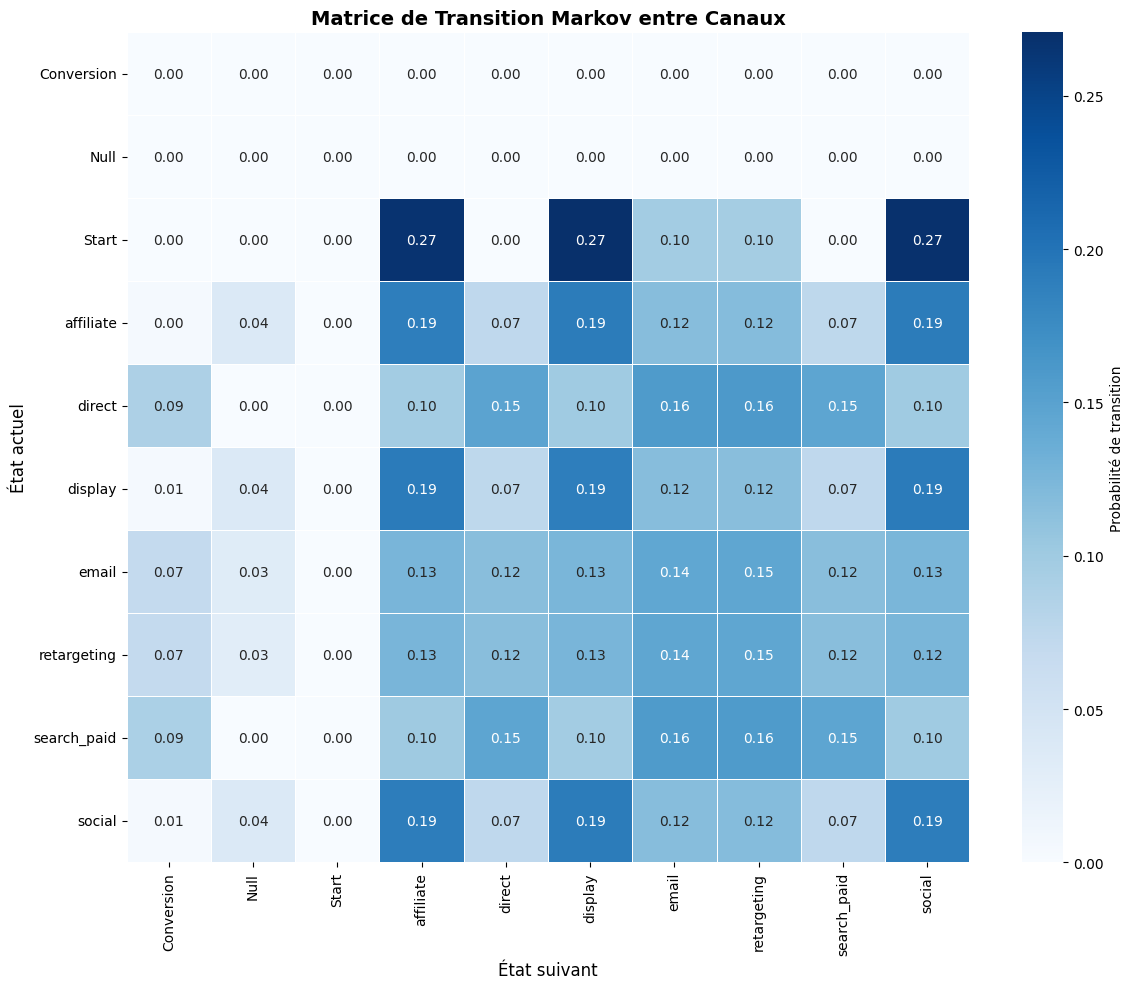

In [27]:
# Visualisation de la matrice de transition (heatmap)
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))

# Filtrer pour ne montrer que les transitions significatives
significant_matrix = transition_matrix.copy()

sns.heatmap(
    significant_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': 'Probabilité de transition'},
    linewidths=0.5
)

ax.set_title('Matrice de Transition Markov entre Canaux', fontsize=14, fontweight='bold')
ax.set_xlabel('État suivant', fontsize=12)
ax.set_ylabel('État actuel', fontsize=12)

plt.tight_layout()
plt.show()

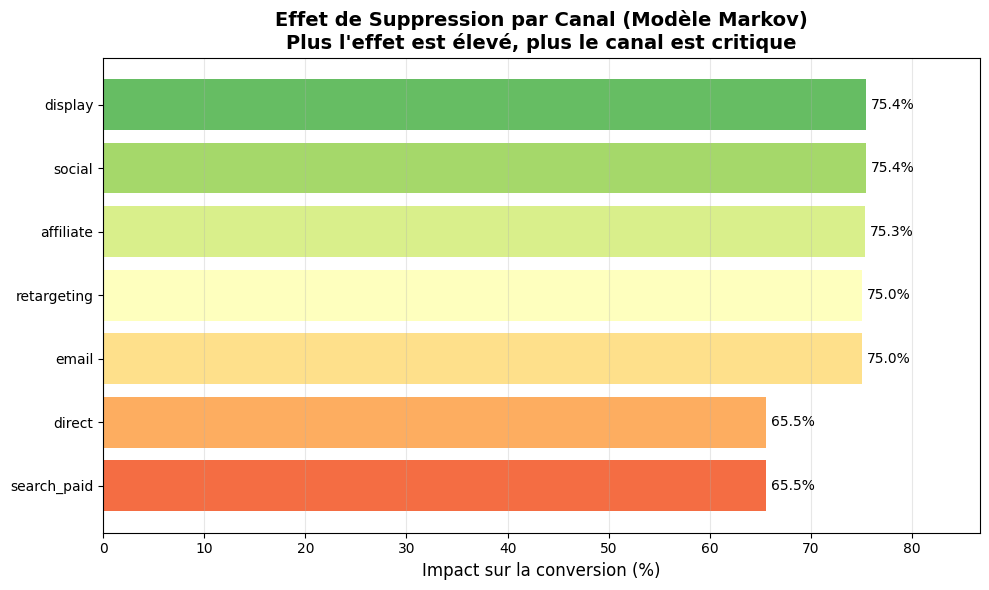


 Interprétation :
Les canaux avec un effet de suppression élevé sont essentiels au parcours de conversion.
Supprimer ces canaux causerait une baisse significative du taux de conversion.


In [29]:
# Visualisation des effets de suppression

fig, ax = plt.subplots(figsize=(10, 6))

df_viz = df_removal.sort_values('removal_effect_pct', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(df_viz)))

bars = ax.barh(df_viz['channel'], df_viz['removal_effect_pct'], color=colors)

ax.set_xlabel('Impact sur la conversion (%)', fontsize=12)
ax.set_title('Effet de Suppression par Canal (Modèle Markov)\nPlus l\'effet est élevé, plus le canal est critique', fontsize=14, fontweight='bold')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, df_viz['removal_effect_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, df_viz['removal_effect_pct'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interprétation :")
print("Les canaux avec un effet de suppression élevé sont essentiels au parcours de conversion.")
print("Supprimer ces canaux causerait une baisse significative du taux de conversion.")